## ***Using their parents’ heights, how can we predict an adult offspring’s height?***

#### Step 1: Import the requried libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import xgboost as xgb

In [2]:
df = pd.read_csv('05-1-galton-x.csv')
df.head()

,Family,Father,Mother,Gender,Height,Kids
0,1,78.5,67.0,M,73.2,4
1,1,78.5,67.0,F,69.2,4
2,1,78.5,67.0,F,69.0,4
3,1,78.5,67.0,F,69.0,4
4,2,75.5,66.5,M,73.5,4


#### Step 2: Preliminary Data Analysis (PDA)

In [3]:
df.shape

(898, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Family  898 non-null    object 
 1   Father  898 non-null    float64
 2   Mother  898 non-null    float64
 3   Gender  898 non-null    object 
 4   Height  898 non-null    float64
 5   Kids    898 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 42.2+ KB


In [5]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
Father,898.0,69.2,2.5,62.0,68.0,69.0,71.0,78.5
Mother,898.0,64.1,2.3,58.0,63.0,64.0,65.5,70.5
Height,898.0,66.8,3.6,56.0,64.0,66.5,69.7,79.0
Kids,898.0,6.1,2.7,1.0,4.0,6.0,8.0,15.0


#### Step 3: Exploratory Data Analysis EDA

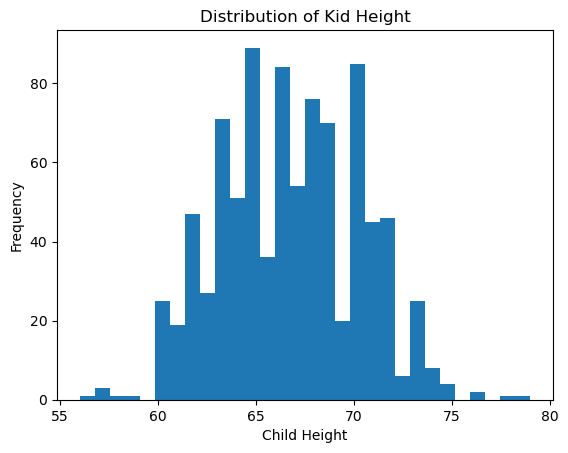

In [6]:
# Kids Height Distribution
plt.figure()
plt.hist(df['Height'], bins=30)
plt.xlabel("Child Height")
plt.ylabel("Frequency")
plt.title("Distribution of Kid Height")
plt.show()

In [7]:
df.Gender.value_counts()

Gender
M    465
F    433
Name: count, dtype: int64

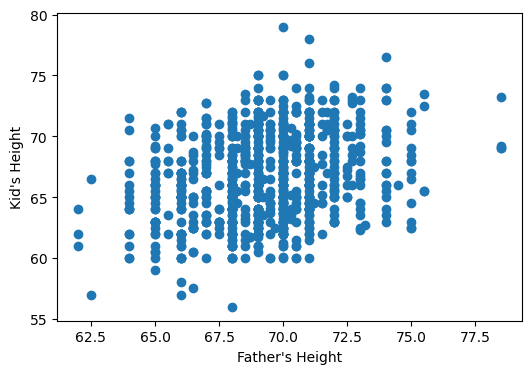

In [8]:
# Scatter plot to visulize the relationship
plt.figure(figsize=(6,4))
plt.scatter(df.Father, df.Height)
plt.xlabel("Father's Height")
plt.ylabel("Kid's Height")
plt.show()

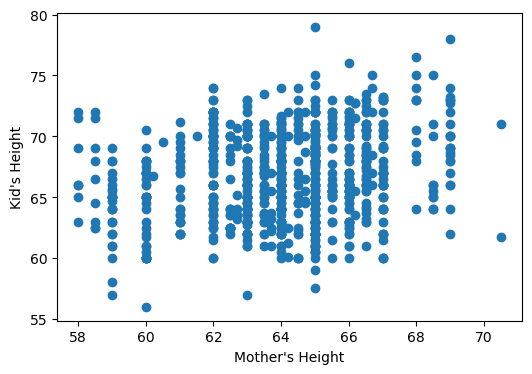

In [9]:
# Scatter plot to visulize the relationship
plt.figure(figsize=(6,4))
plt.scatter(df.Mother, df.Height)
plt.xlabel("Mother's Height")
plt.ylabel("Kid's Height")
plt.show()

In [10]:
corr = df[['Father','Mother','Height']].corr()
print(corr)

          Father    Mother    Height
Father  1.000000  0.073665  0.275355
Mother  0.073665  1.000000  0.201655
Height  0.275355  0.201655  1.000000


#### Step 4: Define Target and Features

In [11]:
y = df.Height
X = df[["Father", "Mother"]]

#### Step 5: First Model

In [12]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Coefficients
print("Intercept:", model.intercept_)
print("Father coefficient:", model.coef_[0])
print("Mother coefficient:", model.coef_[1])

Intercept: 22.309705489589746
Father coefficient: 0.3798969653238257
Mother coefficient: 0.28321451470784825


***First Model:*** 
* **Height=22.3+0.38(Father)+0.28(Mother)**

In [14]:
pred = model.predict(X)

r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))

In [15]:
print(r2)

0.10889519572001294


In [16]:
print(rmse)

3.380332115774557


#### Step 6: Feature Engineering to improve the model

In [17]:
# Label Encoding for Gender
df['Gender_numeric'] = df['Gender'].map({'M':1,'F':0})
df.head()

,Family,Father,Mother,Gender,Height,Kids,Gender_numeric
0,1,78.5,67.0,M,73.2,4,1
1,1,78.5,67.0,F,69.2,4,0
2,1,78.5,67.0,F,69.0,4,0
3,1,78.5,67.0,F,69.0,4,0
4,2,75.5,66.5,M,73.5,4,1


In [18]:
# Average Height of both the parents
df['Average_Height'] = (df['Father'] + df['Mother']) / 2
df.head()

,Family,Father,Mother,Gender,Height,Kids,Gender_numeric,Average_Height
0,1,78.5,67.0,M,73.2,4,1,72.75
1,1,78.5,67.0,F,69.2,4,0,72.75
2,1,78.5,67.0,F,69.0,4,0,72.75
3,1,78.5,67.0,F,69.0,4,0,72.75
4,2,75.5,66.5,M,73.5,4,1,71.00


In [19]:
# Feature Interaction
df['Father_Mother'] = df['Father'] * df['Mother']
df['Father_Gender'] = df['Father'] * df['Gender_numeric']
df['Mother_Gender'] = df['Mother'] * df['Gender_numeric']
df.head()

,Family,Father,Mother,Gender,Height,Kids,Gender_numeric,Average_Height,Father_Mother,Father_Gender,Mother_Gender
0,1,78.5,67.0,M,73.2,4,1,72.75,5259.50,78.5,67.0
1,1,78.5,67.0,F,69.2,4,0,72.75,5259.50,0.0,0.0
2,1,78.5,67.0,F,69.0,4,0,72.75,5259.50,0.0,0.0
3,1,78.5,67.0,F,69.0,4,0,72.75,5259.50,0.0,0.0
4,2,75.5,66.5,M,73.5,4,1,71.00,5020.75,75.5,66.5


***Correlation Matrix of all variables***

In [20]:
df.columns

Index(['Family', 'Father', 'Mother', 'Gender', 'Height', 'Kids',
       'Gender_numeric', 'Average_Height', 'Father_Mother', 'Father_Gender',
       'Mother_Gender'],
      dtype='object')

In [21]:
corr = df[['Height','Father', 'Mother', 'Gender_numeric','Average_Height', 'Father_Mother', 'Father_Gender', 'Mother_Gender']].corr()

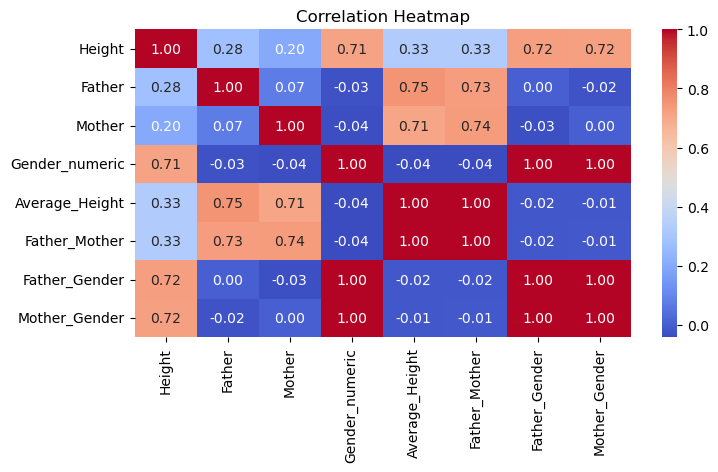

In [22]:
plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### Step 7: Creating multiple model

In [23]:
features = ['Father', 'Mother', 'Gender_numeric', 'Average_Height', 'Father_Mother', 'Father_Gender', 'Mother_Gender']

In [24]:
X = df[features]
y = df['Height']

In [25]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
print(X_train.shape)
print(X_test.shape)

(718, 7)
(180, 7)


***Model 1: Linear Regression Baseline***

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
pred_lr = lr.predict(X_test)

***Model 2: Polynomial Regression***

In [29]:
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scalar', StandardScaler()),
    ('model', LinearRegression())
])

In [30]:
model_poly.fit(X_train, y_train)

,steps,"[('poly', ...), ('scalar', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [31]:
pred_poly = model_poly.predict(X_test)

***Model3: Ridge Regression***

In [32]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1))
])

In [33]:
ridge.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None


In [34]:
pred_ridge = ridge.predict(X_test)

***Model 4: Lasso Regression***

In [35]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1))
])

In [36]:
lasso.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.412e+00, tolerance: 9.339e-01
  model = cd_fast.enet_coordinate_descent(


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True


In [37]:
pred_lasso = lasso.predict(X_test)

***Model 5: Random Forest Regressor***

In [38]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [39]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
pred_rf = rf.predict(X_test)

***Model 6: XGBoost Regressor***

In [41]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4
)

In [42]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
pred_xgb = xgb_model.predict(X_test)

#### Evaluating all the model

In [44]:
def evaluate_model(y_actual, y_pred, model_name):

    r2 = r2_score(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    print(model_name)
    print("R2:", round(r2,4))
    print("RMSE:", round(rmse,4))
    print("---------------")

In [45]:
evaluate_model(y_test, pred_lr, "Linear Regression")
evaluate_model(y_test, pred_poly, "Polynomial Regression")
evaluate_model(y_test, pred_ridge, "Ridge Regression")
evaluate_model(y_test, pred_lasso, "Lasso Regression")
evaluate_model(y_test, pred_rf, "Random Forest")
evaluate_model(y_test, pred_xgb, "XGBoost")

Linear Regression
R2: 0.6098
RMSE: 2.1645
---------------
Polynomial Regression
R2: 0.6045
RMSE: 2.1791
---------------
Ridge Regression
R2: 0.6108
RMSE: 2.1619
---------------
Lasso Regression
R2: 0.6119
RMSE: 2.1587
---------------
Random Forest
R2: 0.5957
RMSE: 2.2033
---------------
XGBoost
R2: 0.6247
RMSE: 2.1229
---------------


***List of Important features:***

In [46]:
importances = rf.feature_importances_
feature_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feature_imp)

Father_Gender     0.530864
Father_Mother     0.150276
Mother_Gender     0.144029
Average_Height    0.067586
Father            0.055101
Mother            0.040424
Gender_numeric    0.011720
dtype: float64
